In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import referenceFrames as rf

In [2]:
sim = Simulation("QuantumEfficiency")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510


# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

In [3]:
# Enable QE

sim["CCD/IncludeQuantumEfficiency"] = "yes"
output = sim.run(removeOutputFile = True)
imageWithQE = output.getImage(0)

# Disable QE

sim["CCD/IncludeQuantumEfficiency"] = "no"
output = sim.run(removeOutputFile = True)
imageWithoutQE = output.getImage(0)


2019-06-13 14:11:51 WARNING Simulation: no information about detected stars to write to HDF5
2019-06-13 14:11:51 WARNING Camera: No star positions to write to HDF5 file.


2019-06-13 14:11:51 WARNING Simulation: no information about detected stars to write to HDF5
2019-06-13 14:11:52 WARNING Camera: No star positions to write to HDF5 file.



In [4]:
quotient = imageWithQE / imageWithoutQE

In [5]:
expectedQE = sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"] * sim["CCD/QuantumEfficiency/MeanAngleDependency"]

In [6]:
distances = np.array([])
qe = np.array([])

for row in range(0, sim["SubField/NumRows"], 500):
    
    for column in range(0, sim["SubField/NumColumns"], 500):
        
        # Calculate the angular distance of pixel (row, column) from the optical axis
        
        xFP, yFP = rf.pixelToFocalPlaneCoordinates(column, row, sim["CCD/PixelSize"], 0, 0, 0)     # Focal-plane coordinates[mm]
        distance = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, sim["Camera/FocalLength/ConstantValue"] * 1000))     # Angular distance from the OA [degrees]
        
        distances = np.append(distances, distance)
        qe = np.append(qe, quotient[row, column])
        

(0, 25)

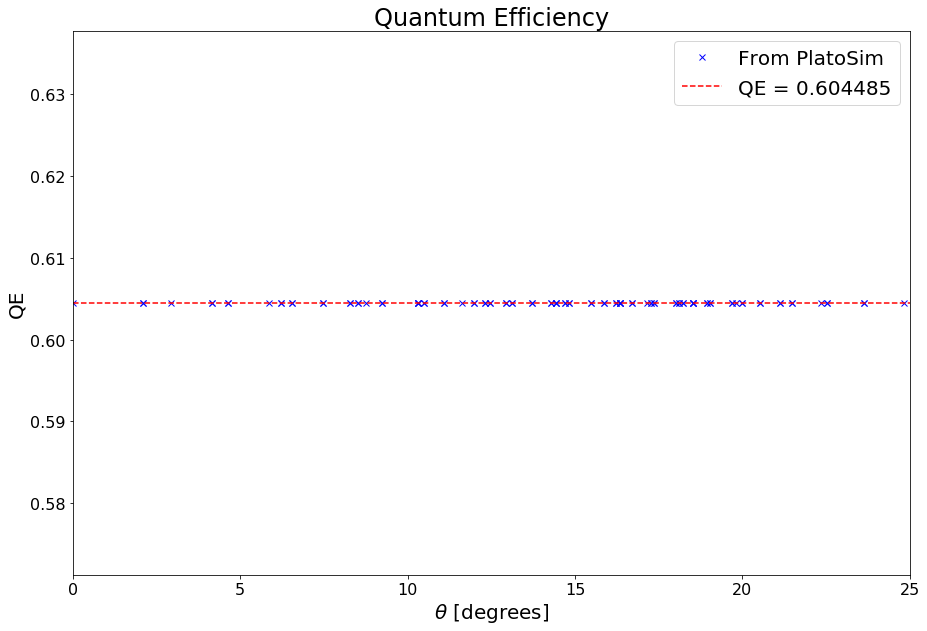

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(distances, qe, "bx", label = "From PlatoSim")



################
# Expected value
################

plt.axhline(y = expectedQE, color = "r", linestyle = "--", label = "QE = " + str(expectedQE))



########
# Layout
########

plt.title("Quantum Efficiency", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$\\theta$ [degrees]", fontsize = 20)
plt.ylabel("QE", fontsize = 20)

plt.xlim([0,25])

It may seems weird to plot the QE vs the angular distance from the optical axis, since the QE is the same everywhere.  This will remain the case until we implement the angle dependency of the QE.  At this moment, however, this has not been characterised yet and a constant value is used for the whole FOV.